# 5 - Misure di Variabilità con R

Questo notebook copre le **misure di variabilità** (o dispersione):
1. **Range** — differenza tra max e min
2. **IQR (Interquartile Range)** — differenza tra Q3 e Q1
3. **Boxplot** — rappresentazione grafica della distribuzione
4. **Varianza e Deviazione Standard** — dispersione attorno alla media
5. **Coefficiente di Variazione (CV)** — variabilità relativa
6. **Indice di Gini** — concentrazione per variabili qualitative
7. **Media e Deviazione Standard per gruppi con dplyr**

---
## Carichiamo il dataset Diamonds

Usiamo il dataset `diamonds` (da ggplot2) che contiene informazioni su prezzi e caratteristiche di diamanti.

In [1]:
# Carichiamo la libreria ggplot2 e il dataset diamonds
library(ggplot2)
data("diamonds")

# Prime righe del dataset
head(diamonds)

# Riepilogo generale
summary(diamonds)

# Attach per accesso diretto alle variabili
attach(diamonds)

carat,cut,color,clarity,depth,table,price,x,y,z
<dbl>,<ord>,<ord>,<ord>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
0.23,Ideal,E,SI2,61.5,55,326,3.95,3.98,2.43
0.21,Premium,E,SI1,59.8,61,326,3.89,3.84,2.31
0.23,Good,E,VS1,56.9,65,327,4.05,4.07,2.31
0.29,Premium,I,VS2,62.4,58,334,4.20,4.23,2.63
0.31,Good,J,SI2,63.3,58,335,4.34,4.35,2.75
0.24,Very Good,J,VVS2,62.8,57,336,3.94,3.96,2.48


     carat               cut        color        clarity          depth      
 Min.   :0.2000   Fair     : 1610   D: 6775   SI1    :13065   Min.   :43.00  
 1st Qu.:0.4000   Good     : 4906   E: 9797   VS2    :12258   1st Qu.:61.00  
 Median :0.7000   Very Good:12082   F: 9542   SI2    : 9194   Median :61.80  
 Mean   :0.7979   Premium  :13791   G:11292   VS1    : 8171   Mean   :61.75  
 3rd Qu.:1.0400   Ideal    :21551   H: 8304   VVS2   : 5066   3rd Qu.:62.50  
 Max.   :5.0100                     I: 5422   VVS1   : 3655   Max.   :79.00  
                                    J: 2808   (Other): 2531                  
     table           price             x                y         
 Min.   :43.00   Min.   :  326   Min.   : 0.000   Min.   : 0.000  
 1st Qu.:56.00   1st Qu.:  950   1st Qu.: 4.710   1st Qu.: 4.720  
 Median :57.00   Median : 2401   Median : 5.700   Median : 5.710  
 Mean   :57.46   Mean   : 3933   Mean   : 5.731   Mean   : 5.735  
 3rd Qu.:59.00   3rd Qu.: 5324   3rd Qu.:

---
## 1. Range e IQR

Il **range** (campo di variazione) è la differenza tra massimo e minimo.
Lo **IQR** (Interquartile Range) è la differenza tra terzo e primo quartile, quindi copre il 50% centrale dei dati.

In [2]:
# Summary del prezzo
summary(price)

# Range: differenza tra max e min
range(price)
18823 - 326  # range calcolato manualmente

# IQR: differenza tra Q3 e Q1
IQR(price)
5324 - 950  # IQR calcolato manualmente (Q3 - Q1)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    326     950    2401    3933    5324   18823 

[1]   326 18823

[1] 18497

[1] 4374.25

[1] 4374

---
## 2. Grafico dei prezzi con quantili

Visualizziamo i prezzi ordinati con linee orizzontali per i quantili.

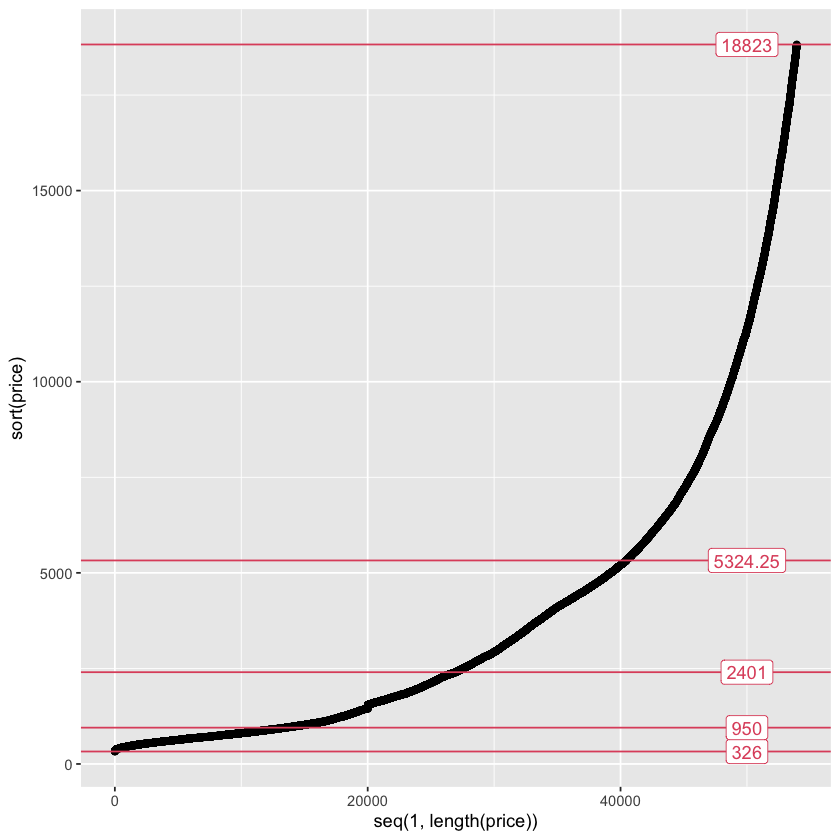

In [3]:
# Grafico a punti dei prezzi ordinati con quantili evidenziati
ggplot() +
  geom_point(aes(x = seq(1, length(price)),
                 y = sort(price))) +
  geom_hline(yintercept = quantile(price), col = 2) +
  geom_label(aes(x = 50000,
                 y = quantile(price),
                 label = quantile(price)),
             col = 2)

---
## 3. Boxplot

Il **boxplot** (diagramma a scatola e baffi) mostra:
- la **mediana** (linea centrale)
- il **IQR** (scatola: da Q1 a Q3)
- i **baffi** fino a 1.5×IQR oltre Q1 e Q3
- i **valori anomali** (punti oltre i baffi)

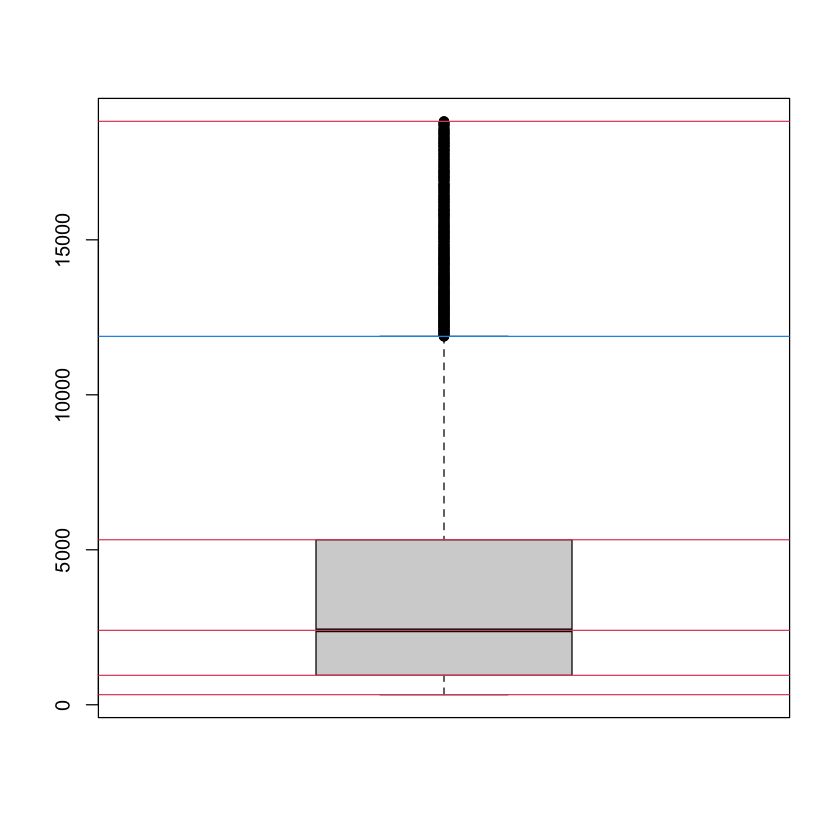

In [4]:
# Boxplot semplice del prezzo
boxplot(price)
abline(h = quantile(price), col = 2)  # linee per i quantili
abline(h = quantile(price, 0.75) + 1.5 * IQR(price), col = 4)  # limite superiore baffo

In [ ]:
# Boxplot del prezzo per colore del diamante
boxplot(price ~ color)

In [ ]:
# Boxplot con ggplot2: prezzo per colore
ggplot(data = diamonds) +
  geom_boxplot(aes(x = color,
                   y = price),
               fill = "lightblue")

In [ ]:
# Boxplot con doppio raggruppamento: prezzo per colore e taglio (cut)
ggplot(data = diamonds) +
  geom_boxplot(aes(x = color,
                   y = price,
                   fill = cut))

---
## 4. Varianza e Deviazione Standard

La **varianza** ($\sigma^2$) misura la dispersione attorno alla media:
$$\sigma^2 = \frac{\sum_{i=1}^{n} (x_i - \mu)^2}{n}$$

La **deviazione standard** ($\sigma$) è la radice quadrata della varianza — nella stessa unità di misura dei dati.

In [5]:
# Calcolo manuale della varianza
mu <- mean(price)
n <- length(price)

sigma2 <- sum((price - mu)^2) / n
sigma2

# Deviazione standard (radice della varianza)
sigma <- sqrt(sigma2)
sigma

[1] 15915334

[1] 3989.403

In [ ]:
# Funzioni built-in
# NOTA: var() in R usa la varianza campionaria (dividendo per n-1), non quella della popolazione
var(price)
sd(price)

---
## 5. Coefficiente di Variazione (CV)

Il **coefficiente di variazione** è una misura di variabilità relativa (adimensionale), utile per confrontare la dispersione tra distribuzioni diverse:
$$CV = \frac{\sigma}{\mu} \times 100$$

Esprime la deviazione standard come percentuale della media.

In [6]:
# Funzione per il coefficiente di variazione
CV <- function(x) {
  return(sd(x) / mean(x) * 100)
}

# CV del prezzo
CV(price)

[1] 101.4402

---
## 6. Indice di Gini (normalizzato)

L'**indice di Gini** misura la concentrazione (o eterogeneità) per variabili qualitative nominali.
- Varia tra 0 (massima concentrazione: tutti i valori nella stessa categoria) e 1 (massima eterogeneità: uniforme)
- La versione **normalizzata** divide per $(J-1)/J$ dove J è il numero di categorie

In [7]:
# Funzione per l'indice di Gini normalizzato
gini.index <- function(x) {
  ni <- table(x)
  fi <- ni / length(x)
  fi2 <- fi^2
  J <- length(table(x))
  
  gini <- 1 - sum(fi2)
  gini.norm <- gini / ((J - 1) / J)
  
  return(gini.norm)
}

# Frequenze relative per colore
table(color) / length(color)

# Indice di Gini per la variabile color
gini.index(color)

color
         D          E          F          G          H          I          J 
0.12560252 0.18162773 0.17690026 0.20934372 0.15394883 0.10051910 0.05205784 

[1] 0.9795363

---
## 7. Media e Deviazione Standard per gruppi con dplyr

Usiamo `dplyr` per calcolare media e deviazione standard della variabile `depth` raggruppata per `cut` (taglio del diamante).

In [8]:
# Installiamo e carichiamo dplyr se necessario
# install.packages("dplyr")
library(dplyr)

# Media e deviazione standard di depth per ogni cut
depth_mu_sigma <- 
  diamonds %>% 
  group_by(cut) %>% 
  summarise(media = mean(depth),
            devst = sd(depth))

depth_mu_sigma


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




cut,media,devst
<ord>,<dbl>,<dbl>
Fair,64.04168,3.6434275
Good,62.36588,2.1693739
Very Good,61.81828,1.3786308
Premium,61.26467,1.1588149
Ideal,61.70940,0.7185386


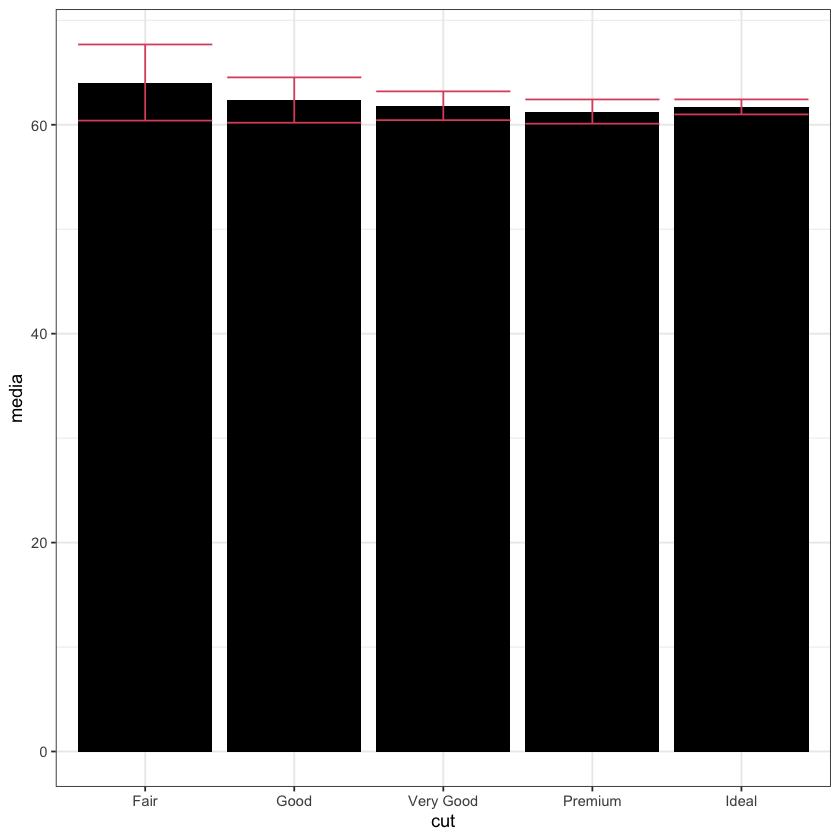

In [9]:
# Grafico a barre con barre di errore (± 1 deviazione standard)
ggplot(depth_mu_sigma) +
  theme_bw() +
  geom_col(aes(x = cut, y = media), fill = "black") +
  geom_errorbar(aes(x = cut,
                    ymin = media - devst,
                    ymax = media + devst),
                col = 2)